# PDF Information Extraction Comparison

This notebook compares two popular PDF extraction libraries:
- **PyMuPDF (fitz)**: Fast, low-level PDF processing
- **Unstructured**: AI-powered document parsing with semantic understanding

## Sections:
1. Utility Preparation
2. PyMuPDF Extraction
3. Unstructured Extraction
4. Comparison & Analysis


In [1]:
# Section 1: Utility Preparation

import fitz  # PyMuPDF
from unstructured.partition.auto import partition
import time
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import io

# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# PDF file path
PDF_PATH = "the-state-of-ai-how-organizations-are-rewiring-to-capture-value_final.pdf"

# Verify PDF exists
if os.path.exists(PDF_PATH):
    print(f"✓ PDF found: {PDF_PATH}")
    print(f"  File size: {os.path.getsize(PDF_PATH) / 1024 / 1024:.2f} MB")
else:
    print(f"✗ PDF not found: {PDF_PATH}")


✓ PDF found: the-state-of-ai-how-organizations-are-rewiring-to-capture-value_final.pdf
  File size: 5.31 MB


In [2]:
# Utility functions for visualization and comparison

def extract_page_as_image(pdf_path, page_num=0, dpi=150):
    """Extract a page as an image for visualization."""
    doc = fitz.open(pdf_path)
    page = doc[page_num]
    pix = page.get_pixmap(dpi=dpi)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()
    return img

def highlight_text_blocks(pdf_path, page_num=0, dpi=150):
    """Visualize text blocks on a PDF page."""
    doc = fitz.open(pdf_path)
    page = doc[page_num]
    
    # Get page as image
    pix = page.get_pixmap(dpi=dpi)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 16))
    ax.imshow(img)
    
    # Get text blocks
    blocks = page.get_text("dict")["blocks"]
    
    # Draw rectangles around text blocks
    scale = dpi / 72  # Convert PDF points to pixels
    for block in blocks:
        if "lines" in block:  # Text block
            x0, y0, x1, y1 = block["bbox"]
            rect = patches.Rectangle((x0 * scale, y0 * scale), 
                                     (x1 - x0) * scale, (y1 - y0) * scale,
                                     linewidth=2, edgecolor='red', facecolor='none', alpha=0.7)
            ax.add_patch(rect)
    
    ax.set_title(f"Text Block Detection - Page {page_num + 1}", fontsize=14, fontweight='bold')
    ax.axis('off')
    doc.close()
    plt.tight_layout()
    return fig

def format_time(seconds):
    """Format time in a readable way."""
    if seconds < 1:
        return f"{seconds * 1000:.2f} ms"
    return f"{seconds:.2f} s"

print("✓ Utility functions loaded")


✓ Utility functions loaded


In [3]:
# Unstructured visualization methods

def highlight_unstructured_elements(pdf_path, elements, page_num=0, dpi=200, element_colors=None, min_box=1.0):
    """
    Direct rendering of bounding boxes on PDF page using PyMuPDF's drawing tools
    instead of trying to convert coordinates between different systems
    """
    import fitz
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from PIL import Image
    import io
    import numpy as np
    
    # Define colors for different element types
    if element_colors is None:
        element_colors = {
            "Title": (1, 0, 0),         # Red
            "NarrativeText": (0, 0, 1),  # Blue
            "ListItem": (1, 0.65, 0),    # Orange
            "Table": (0, 0.8, 0),        # Green
            "Image": (1, 0, 1),          # Magenta
            "Header": (0.5, 0, 0.5),     # Purple
            "Footer": (0, 0.5, 0.5),     # Teal
            "FigureCaption": (1, 0.84, 0), # Gold
            "PageNumber": (0.5, 0.5, 0.5), # Gray
            "Text": (0.5, 0.25, 0),      # Brown
        }
    
    # Convert matplotlib colors to fitz colors (keeping 0-1 range)
    fitz_colors = {}
    for elem_type, rgb in element_colors.items():
        # Convert string colors to RGB if needed, but keep in 0-1 range
        if isinstance(rgb, str):
            rgb = mcolors.to_rgb(rgb)
        fitz_colors[elem_type] = rgb  # PyMuPDF expects colors in 0-1 range
    
    # Open the PDF
    doc = fitz.open(pdf_path)
    page = doc[page_num]
    
    # Create a copy of the page for annotation
    pix = page.get_pixmap(dpi=dpi)
    
    # Filter elements for current page
    page_elems = []
    for e in elements:
        if hasattr(e, "metadata") and hasattr(e.metadata, "page_number"):
            if e.metadata.page_number == page_num + 1:
                page_elems.append(e)
    
    # Create a PDF document for annotations
    annotated_pdf = fitz.open()
    annotated_page = annotated_pdf.new_page(width=page.rect.width, height=page.rect.height)
    
    # First, insert the original page content
    annotated_page.show_pdf_page(annotated_page.rect, doc, page_num)
    
    # Add annotations for each element
    drawn = 0
    for elem in page_elems:
        elem_type = type(elem).__name__
        
        # Get element text to search in document
        elem_text = str(elem).strip()
        if not elem_text or len(elem_text) < 4:  # Skip very short elements
            continue
        
        # Search for the text in the page
        # We'll try a few different strategies
        text_instances = page.search_for(elem_text[:min(50, len(elem_text))])
        
        if not text_instances and len(elem_text) > 10:
            # Try with a shorter substring if we didn't find anything
            text_instances = page.search_for(elem_text[:min(20, len(elem_text))])
            
        if not text_instances and len(elem_text) > 20:
            # Try with just the first few words
            first_words = ' '.join(elem_text.split()[:5])
            text_instances = page.search_for(first_words)
        
        # Draw rectangles for found text
        for rect in text_instances:
            color = fitz_colors.get(elem_type, (0, 0.6, 0.8))
            
            # Draw rectangle on the annotated page
            annotated_page.draw_rect(rect, color=color, width=2)
            
            # Add a small label with the element type
            annotated_page.insert_text(
                fitz.Point(rect.x0, rect.y0 - 5),
                elem_type,
                fontsize=8,
                color=color
            )
            
            drawn += 1
    
    # Add a title
    annotated_page.insert_text(
        fitz.Point(50, 30),
        f"Unstructured - Page {page_num + 1}\n{len(page_elems)} elements ({drawn} boxes)",
        fontsize=14,
        color=(0, 0, 0)
    )
    
    # Convert the annotated page to an image
    annotated_pix = annotated_page.get_pixmap(dpi=dpi)
    annotated_img = Image.frombytes("RGB", [annotated_pix.width, annotated_pix.height], annotated_pix.samples)
    
    # Display the image using matplotlib
    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(annotated_img)
    ax.axis('off')
    
    # Clean up
    doc.close()
    annotated_pdf.close()
    
    return fig

def plot_pdf_with_boxes(pdf_path, elements, page_num=0):
    """
    Alternative visualization that uses the Unstructured coordinate data directly.
    Renders PDF using PyMuPDF and plots element boxes with matplotlib.
    """
    import fitz
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    from PIL import Image
    
    # Open PDF and get the specified page
    doc = fitz.open(pdf_path)
    page = doc[page_num]
    
    # Render page as an image
    pix = page.get_pixmap()
    pil_image = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    
    # Create figure
    fig, ax = plt.subplots(1, figsize=(10, 14))
    ax.imshow(pil_image)
    
    # Define colors for different element types
    category_to_color = {
        "Title": "orchid",
        "Image": "forestgreen",
        "Table": "tomato",
        "NarrativeText": "deepskyblue",
        "ListItem": "gold",
        "FigureCaption": "darkorange"
    }
    
    # Filter elements for current page
    page_elems = [e for e in elements if hasattr(e, "metadata") 
                 and getattr(e.metadata, "page_number", None) == page_num + 1]
    
    # Track categories for legend
    categories = set()
    drawn_count = 0
    
    # Process each element
    for element in page_elems:
        # Get element metadata and coordinates
        elem_type = type(element).__name__
        metadata = getattr(element, "metadata", None)
        
        # Skip if no metadata or coordinates
        if not metadata or not hasattr(metadata, "coordinates"):
            continue
            
        coords = metadata.coordinates
        if not hasattr(coords, "points") or not coords.points:
            continue
            
        # Get layout dimensions
        layout_width = getattr(coords, "layout_width", page.rect.width)
        layout_height = getattr(coords, "layout_height", page.rect.height)
        
        # Extract and scale points
        points = coords.points
        scaled_points = [
            (x * pix.width / layout_width, y * pix.height / layout_height)
            for x, y in points
        ]
        
        # Choose box color based on element type
        box_color = category_to_color.get(elem_type, "deepskyblue")
        categories.add(elem_type)
        
        # Draw polygon for this element
        rect = patches.Polygon(
            scaled_points, linewidth=1.5, edgecolor=box_color, facecolor='none', alpha=0.8
        )
        ax.add_patch(rect)
        
        # Add label with element type
        centroid_x = sum(p[0] for p in scaled_points) / len(scaled_points)
        centroid_y = sum(p[1] for p in scaled_points) / len(scaled_points)
        ax.text(centroid_x, centroid_y, elem_type, fontsize=8, color='black',
                bbox=dict(facecolor=box_color, alpha=0.7, boxstyle="round,pad=0.1"))
        
        drawn_count += 1
    
    # Create legend
    legend_handles = []
    for category in set(categories):
        if category in category_to_color:
            legend_handles.append(
                patches.Patch(color=category_to_color[category], label=category)
            )
    
    # Set title and legend
    ax.set_title(f"PDF Elements - Page {page_num + 1}\n{len(page_elems)} elements detected", 
                fontsize=14, fontweight='bold')
    if legend_handles:
        ax.legend(handles=legend_handles, loc="upper right")
    
    # Turn off axes and tighten layout
    ax.axis('off')
    plt.tight_layout()
    
    # Clean up
    doc.close()
    
    return fig

def render_page(elements, pdf_path, page_number, print_text=True):
    """
    Renders a PDF page with Unstructured element boxes and optionally prints element text.
    
    Args:
        elements: List of Unstructured elements
        pdf_path: Path to the PDF file
        page_number: Page number to render (1-based)
        print_text: Whether to print extracted text for each element
    """
    # Adjust to 0-based indexing for PyMuPDF
    page_index = page_number - 1
    
    # Filter elements for this page
    page_elems = [e for e in elements if hasattr(e, "metadata") 
                 and getattr(e.metadata, "page_number", None) == page_number]
    
    # Visualize using plot_pdf_with_boxes
    fig = plot_pdf_with_boxes(pdf_path, elements, page_num=page_index)
    plt.show()
    
    # Print text content if requested
    if print_text and page_elems:
        print(f"\n==== Text content from page {page_number} ====")
        for i, elem in enumerate(page_elems, 1):
            elem_type = type(elem).__name__
            print(f"\n[{i}] {elem_type}:")
            print(f"{str(elem)[:500]}" + ("..." if len(str(elem)) > 500 else ""))


---
## Section 2: PyMuPDF Extraction

PyMuPDF is a fast, lightweight PDF library with direct access to PDF structure.


In [4]:
# Extract with PyMuPDF
print("=" * 60)
print("PyMuPDF EXTRACTION")
print("=" * 60)

start_time = time.time()

# Open PDF
doc = fitz.open(PDF_PATH)

# Extract metadata
pymupdf_metadata = {
    "pages": doc.page_count,
    "title": doc.metadata.get("title", "N/A"),
    "author": doc.metadata.get("author", "N/A"),
    "producer": doc.metadata.get("producer", "N/A"),
}

# Extract text from all pages
pymupdf_text = []
pymupdf_blocks = []
for page_num in range(doc.page_count):
    page = doc[page_num]
    pymupdf_text.append(page.get_text())
    
    # Get structured blocks
    blocks = page.get_text("dict")["blocks"]
    for block in blocks:
        if "lines" in block:
            pymupdf_blocks.append({
                "page": page_num + 1,
                "type": "text",
                "bbox": block["bbox"],
                "content": " ".join([
                    " ".join([span["text"] for span in line["spans"]])
                    for line in block["lines"]
                ])
            })

doc.close()

pymupdf_time = time.time() - start_time

# Summary
print(f"\n✓ Extraction completed in {format_time(pymupdf_time)}")
print(f"  Pages: {pymupdf_metadata['pages']}")
print(f"  Text blocks extracted: {len(pymupdf_blocks)}")
print(f"  Total characters: {sum(len(t) for t in pymupdf_text):,}")
print(f"\nFirst 500 characters:\n{pymupdf_text[0][:500]}...")


PyMuPDF EXTRACTION

✓ Extraction completed in 271.16 ms
  Pages: 26
  Text blocks extracted: 859
  Total characters: 50,949

First 500 characters:
The state of AI 
March 2025
Alex Singla 
Alexander Sukharevsky 
Lareina Yee 
Michael Chui
Bryce Hall
How organizations are rewiring to capture value
...


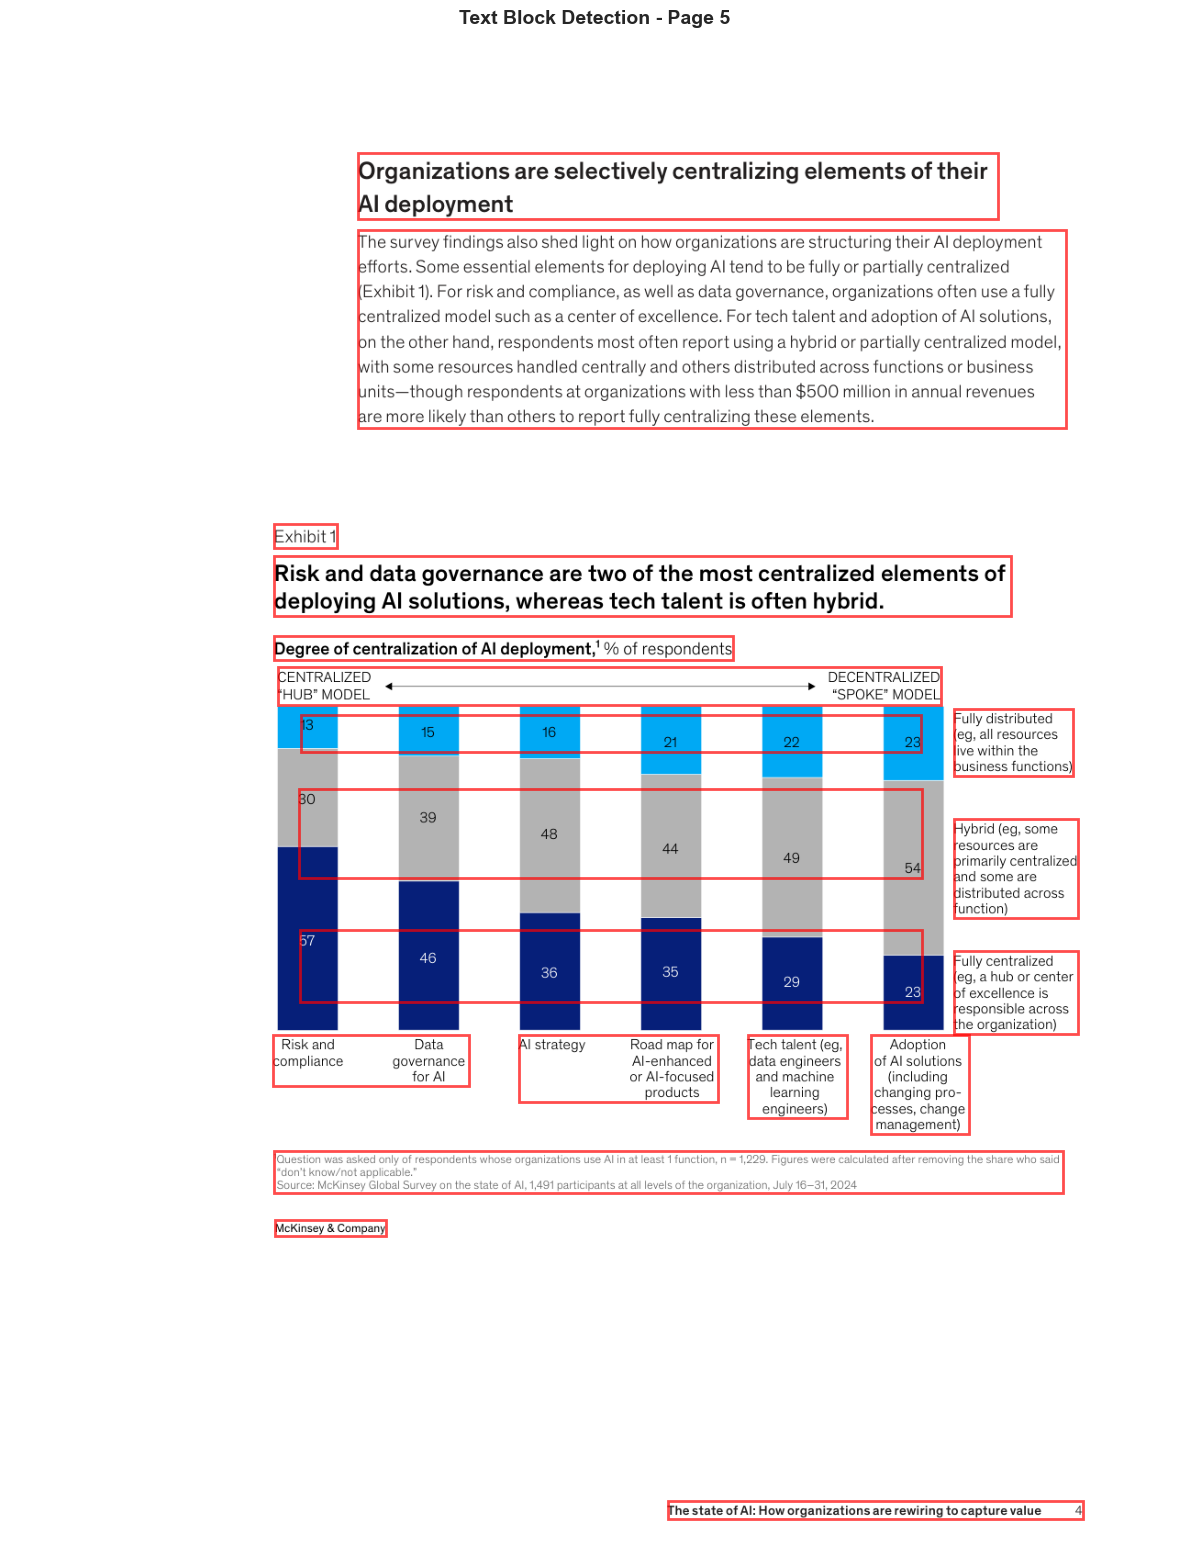

In [5]:
# Visualize PyMuPDF text block detection
highlight_text_blocks(PDF_PATH, page_num=4)
plt.show()


In [6]:
# Convert PyMuPDF extraction to Markdown
def pymupdf_to_markdown(text_list):
    """Convert PyMuPDF text to markdown."""
    markdown = []
    for i, page_text in enumerate(text_list):
        markdown.append(f"# Page {i + 1}\n\n{page_text.strip()}\n\n---\n")
    return "\n".join(markdown)

pymupdf_markdown = pymupdf_to_markdown(pymupdf_text[:3])  # First 3 pages
print("PyMuPDF Markdown Output (first 3 pages):")
print("=" * 60)
print(pymupdf_markdown[:1000])
print("...")


PyMuPDF Markdown Output (first 3 pages):
# Page 1

The state of AI 
March 2025
Alex Singla 
Alexander Sukharevsky 
Lareina Yee 
Michael Chui
Bryce Hall
How organizations are rewiring to capture value

---

# Page 2

Organizations are beginning to create the
structures and processes that lead to 
meaningful value from gen AI. While 
still in early days, companies are 
redesigning workflows, elevating 
governance, and mitigating 
more risks.   
O
rganizations are starting to make 
organizational changes designed to 
generate future value from gen AI, and 
large companies are leading the way. The 
latest McKinsey Global Survey on AI finds 
that organizations are beginning to take steps that drive 
bottom-line impact—for example, redesigning workflows as 
they deploy gen AI and putting senior leaders in critical roles, 
such as overseeing AI governance. The findings also show 
that organizations are working to mitigate a growing set of 
gen-AI-related risks and are hiring for new AI-relate

---
## Section 3: Unstructured Extraction

Unstructured uses AI/ML to understand document structure and semantics.


In [7]:
# Extract with Unstructured + PaddleOCR
print("=" * 60)
print("UNSTRUCTURED EXTRACTION WITH PADDLEOCR")
print("=" * 60)

# Check if paddleocr is installed
try:
    import importlib.util
    paddle_spec = importlib.util.find_spec("paddleocr")
    paddle_installed = paddle_spec is not None
    if not paddle_installed:
        print("⚠️ PaddleOCR not installed. To install: pip install paddleocr paddlenlp")
        print("⚠️ Using default OCR engine instead of PaddleOCR")
except ImportError:
    paddle_installed = False
    print("⚠️ Cannot check for PaddleOCR. Please install with: pip install paddleocr paddlenlp")

# Check if html2text is installed
try:
    import importlib.util
    html2text_spec = importlib.util.find_spec("html2text")
    html2text_installed = html2text_spec is not None
    if not html2text_installed:
        print("⚠️ html2text not installed. To install: pip install html2text")
except ImportError:
    html2text_installed = False
    print("⚠️ Cannot check for html2text. Please install with: pip install html2text")

start_time = time.time()

# Partition PDF with Unstructured using enhanced settings
ocr_params = {}
if paddle_installed:
    ocr_params = {
        "strategy": "hi_res",             # High resolution mode for complex documents
        "infer_table_structure": True,    # Auto-detect table structure
        "languages": ["en", "zh"],        # Support English and Chinese
        "ocr_languages": "chi_sim+eng",   # Chinese simplified + English
        "ocr_engine": "paddleocr"         # Use PaddleOCR for better accuracy
    }
else:
    ocr_params = {
        "strategy": "hi_res",             # High resolution mode
        "infer_table_structure": True,    # Auto-detect table structure
        "languages": ["en"]               # Default to English only
    }

# Extract elements with enhanced params
elements = partition(PDF_PATH, **ocr_params)

unstructured_time = time.time() - start_time

# Analyze elements
element_types = {}
for elem in elements:
    elem_type = type(elem).__name__
    element_types[elem_type] = element_types.get(elem_type, 0) + 1

# Summary
print(f"\n✓ Extraction completed in {format_time(unstructured_time)}")
print(f"  Total elements: {len(elements)}")
print(f"  Element types: {len(element_types)}")
print(f"\nElement type breakdown:")
for elem_type, count in sorted(element_types.items(), key=lambda x: x[1], reverse=True):
    print(f"  - {elem_type}: {count}")

print(f"\nFirst 5 elements:")
for i, elem in enumerate(elements[:5]):
    print(f"\n[{i+1}] {type(elem).__name__}:")
    print(f"    {str(elem)[:200]}...")


The ocr_languages kwarg will be deprecated in a future version of unstructured. Please use languages instead.


UNSTRUCTURED EXTRACTION WITH PADDLEOCR


The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.



✓ Extraction completed in 91.74 s
  Total elements: 285
  Element types: 9

Element type breakdown:
  - NarrativeText: 138
  - Title: 58
  - Text: 47
  - Image: 20
  - FigureCaption: 8
  - ListItem: 7
  - Table: 5
  - Header: 1
  - Footer: 1

First 5 elements:

[1] Title:
    ( \, QuantumBlack ~ AI by McKinsey...

[2] Title:
    The state of AI How organizations are rewiring to capture value...

[3] NarrativeText:
    Alex Singla Alexander Sukharevsky Lareina Yee Michael Chui Bryce Hall...

[4] NarrativeText:
    March 2025...

[5] Image:
    ...


In [8]:
# Enhanced PDF to Markdown conversion with image extraction
import os
import fitz
import html2text as html2text_converter

def pdf_to_markdown_with_images(elements, pdf_path, output_dir="pdf_images"):
    """
    Convert PDF to Markdown with enhanced features:
    - Extract and save images
    - Convert tables to Markdown format
    - Properly format different element types
    - Link images in the Markdown output
    """
    # Create output directory for images
    os.makedirs(output_dir, exist_ok=True)
    
    # Step 1: Extract images from PDF using PyMuPDF
    doc = fitz.open(pdf_path)
    image_map = {}  # Mapping page_number -> list of image paths
    
    for page_num, page in enumerate(doc, start=1):
        image_map[page_num] = []
        for img_index, img in enumerate(page.get_images(full=True), start=1):
            xref = img[0]
            pix = fitz.Pixmap(doc, xref)
            img_path = os.path.join(output_dir, f"page{page_num}_img{img_index}.png")
            
            # Convert CMYK to RGB if needed
            if pix.n < 5:  # RGB or Gray
                pix.save(img_path)
            else:  # CMYK
                pix = fitz.Pixmap(fitz.csRGB, pix)
                pix.save(img_path)
            
            image_map[page_num].append(img_path)
    
    # Step 2: Build Markdown content from elements
    md_lines = []
    inserted_images = set()  # Track inserted images to avoid duplicates
    
    for elem in elements:
        elem_type = type(elem).__name__
        text = str(elem)
        page_num = getattr(elem.metadata, "page_number", None)
        
        if elem_type == "Title" and text.strip().startswith("- "):
            md_lines.append(f"{text}\n")  # List item mistakenly classified as title
        elif elem_type == "Title":
            md_lines.append(f"# {text}\n")
        elif elem_type in ["Header", "Subheader"]:
            md_lines.append(f"## {text}\n")
        elif elem_type == "ListItem":
            md_lines.append(f"- {text}\n")
        elif elem_type == "Table":
            # Try to convert table to Markdown format if HTML is available
            if hasattr(elem.metadata, "text_as_html") and elem.metadata.text_as_html:
                try:
                    # Use html2text to convert HTML table to Markdown
                    h2t = html2text_converter.HTML2Text()
                    h2t.ignore_links = False
                    h2t.bypass_tables = False
                    md_table = h2t.handle(elem.metadata.text_as_html)
                    md_lines.append(f"\n{md_table}\n")
                except Exception:
                    # Fallback to plain text if conversion fails
                    md_lines.append(f"\n{text}\n")
            else:
                md_lines.append(f"\n{text}\n")
        elif elem_type == "Image":
            # Insert reference to extracted image
            if page_num and page_num in image_map:
                for img_path in image_map.get(page_num, []):
                    if img_path not in inserted_images:
                        md_lines.append(f"![Image](./{img_path})\n\n")
                        inserted_images.add(img_path)
        else:
            # Default handling for other element types
            md_lines.append(f"{text}\n\n")
    
    # Close the PDF document
    doc.close()
    
    # Return the Markdown content
    return "\n".join(md_lines), len(inserted_images)

# Try basic conversion for demo purposes
try:
    # Check if html2text is available
    import importlib.util
    html2text_spec = importlib.util.find_spec("html2text")
    html2text_installed = html2text_spec is not None
    
    if html2text_installed:
        unstructured_markdown, img_count = pdf_to_markdown_with_images(
            elements[:50],  # First 50 elements for demo
            PDF_PATH,
            output_dir="pdf_images_demo"
        )
        print(f"Enhanced Markdown Output (with {img_count} images extracted):")
        print("=" * 60)
        print(unstructured_markdown[:1000])
        print("...")
    else:
        print("⚠️ html2text not installed. Using simple Markdown conversion instead.")
        
        # Simple conversion as fallback
        def unstructured_to_markdown(elements):
            """Convert Unstructured elements to markdown."""
            markdown = []
            for elem in elements:
                elem_type = type(elem).__name__
                text = str(elem)

                if elem_type == "Title":
                    markdown.append(f"# {text}\n")
                elif elem_type == "NarrativeText":
                    markdown.append(f"{text}\n")
                elif elem_type == "ListItem":
                    markdown.append(f"- {text}\n")
                elif elem_type == "Table":
                    markdown.append(f"\n{text}\n")
                else:
                    markdown.append(f"{text}\n")
            
            return "\n".join(markdown)

        unstructured_markdown = unstructured_to_markdown(elements[:50])
        print("Basic Unstructured Markdown Output (first 50 elements):")
        print("=" * 60)
        print(unstructured_markdown[:1000])
        print("...")
except Exception as e:
    print(f"⚠️ Error during Markdown conversion: {e}")
    
    # Simple conversion as fallback
    def unstructured_to_markdown(elements):
        """Simple conversion of elements to Markdown."""
        markdown = []
        for elem in elements:
            elem_type = type(elem).__name__
            text = str(elem)

            if elem_type == "Title":
                markdown.append(f"# {text}\n")
            else:
                markdown.append(f"{text}\n")
        
        return "\n".join(markdown)
    
    unstructured_markdown = unstructured_to_markdown(elements[:50])
    print("Fallback Markdown Output (first 50 elements):")
    print("=" * 60)
    print(unstructured_markdown[:1000])
    print("...")


Enhanced Markdown Output (with 6 images extracted):
# ( \, QuantumBlack ~ AI by McKinsey

# The state of AI How organizations are rewiring to capture value

Alex Singla Alexander Sukharevsky Lareina Yee Michael Chui Bryce Hall


March 2025


![Image](./pdf_images_demo/page1_img1.png)


![Image](./pdf_images_demo/page1_img2.png)


Organizations are beginning to create structures and processes that lead to meaningful value from gen Al. While still in early days, companies are redesigning workflows, elevating governance, and mitigating more risks.


the


![Image](./pdf_images_demo/page2_img1.png)


![Image](./pdf_images_demo/page2_img2.png)


rganizations are starting to make organizational changes designed to generate future value from gen Al, and large companies are leading the way. The latest McKinsey Global Survey on Al finds


latest McKinsey Global Survey on Al finds that organizations are beginning to take steps that drive bottom-line impact—for example, redesigning workflows as t

---
## Section 4: Comparison & Analysis

Let's compare the two libraries across multiple dimensions.


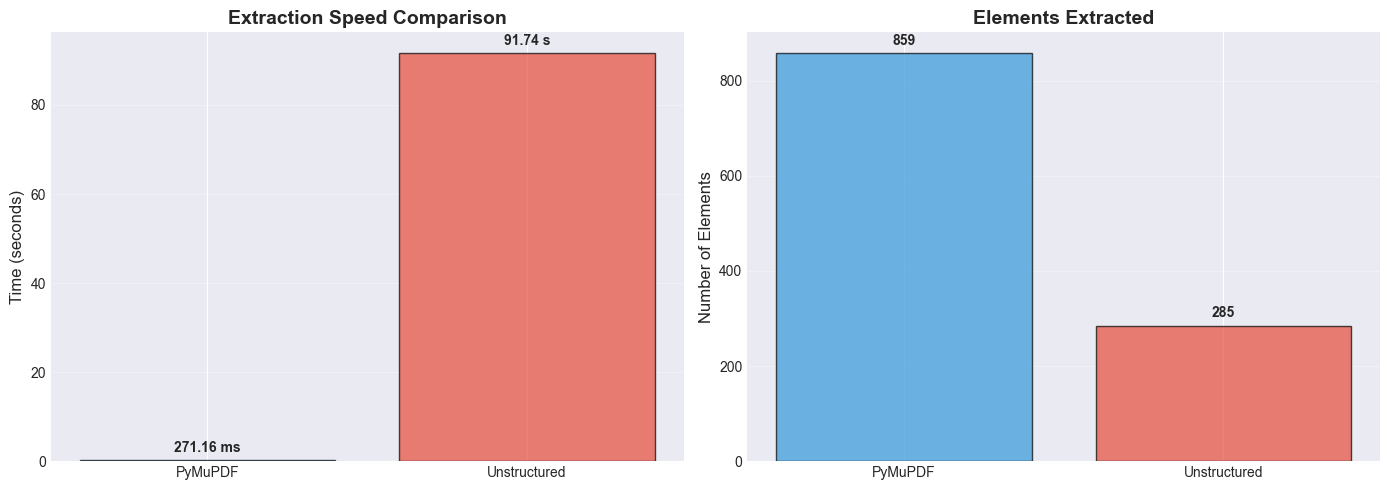

In [9]:
# Visualize performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed comparison
libraries = ["PyMuPDF", "Unstructured"]
times = [pymupdf_time, unstructured_time]
colors = ["#3498db", "#e74c3c"]

axes[0].bar(libraries, times, color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel("Time (seconds)", fontsize=12)
axes[0].set_title("Extraction Speed Comparison", fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (lib, t) in enumerate(zip(libraries, times)):
    axes[0].text(i, t + max(times) * 0.02, format_time(t), ha='center', fontweight='bold')

# Element count comparison
element_counts = [len(pymupdf_blocks), len(elements)]
axes[1].bar(libraries, element_counts, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel("Number of Elements", fontsize=12)
axes[1].set_title("Elements Extracted", fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (lib, count) in enumerate(zip(libraries, element_counts)):
    axes[1].text(i, count + max(element_counts) * 0.02, f"{count:,}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 📊 Page-by-Page Visual Comparison

Compare element detection side-by-side for individual pages.

Preparing visualization for Page 2...
Alternative visualization using element coordinates:
--------------------------------------------------
Running render_page() for direct coordinate-based visualization


/var/folders/47/rlzyr75n4s10_97pdbpn0j2r0000gn/T/ipykernel_20290/2989927181.py:221: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


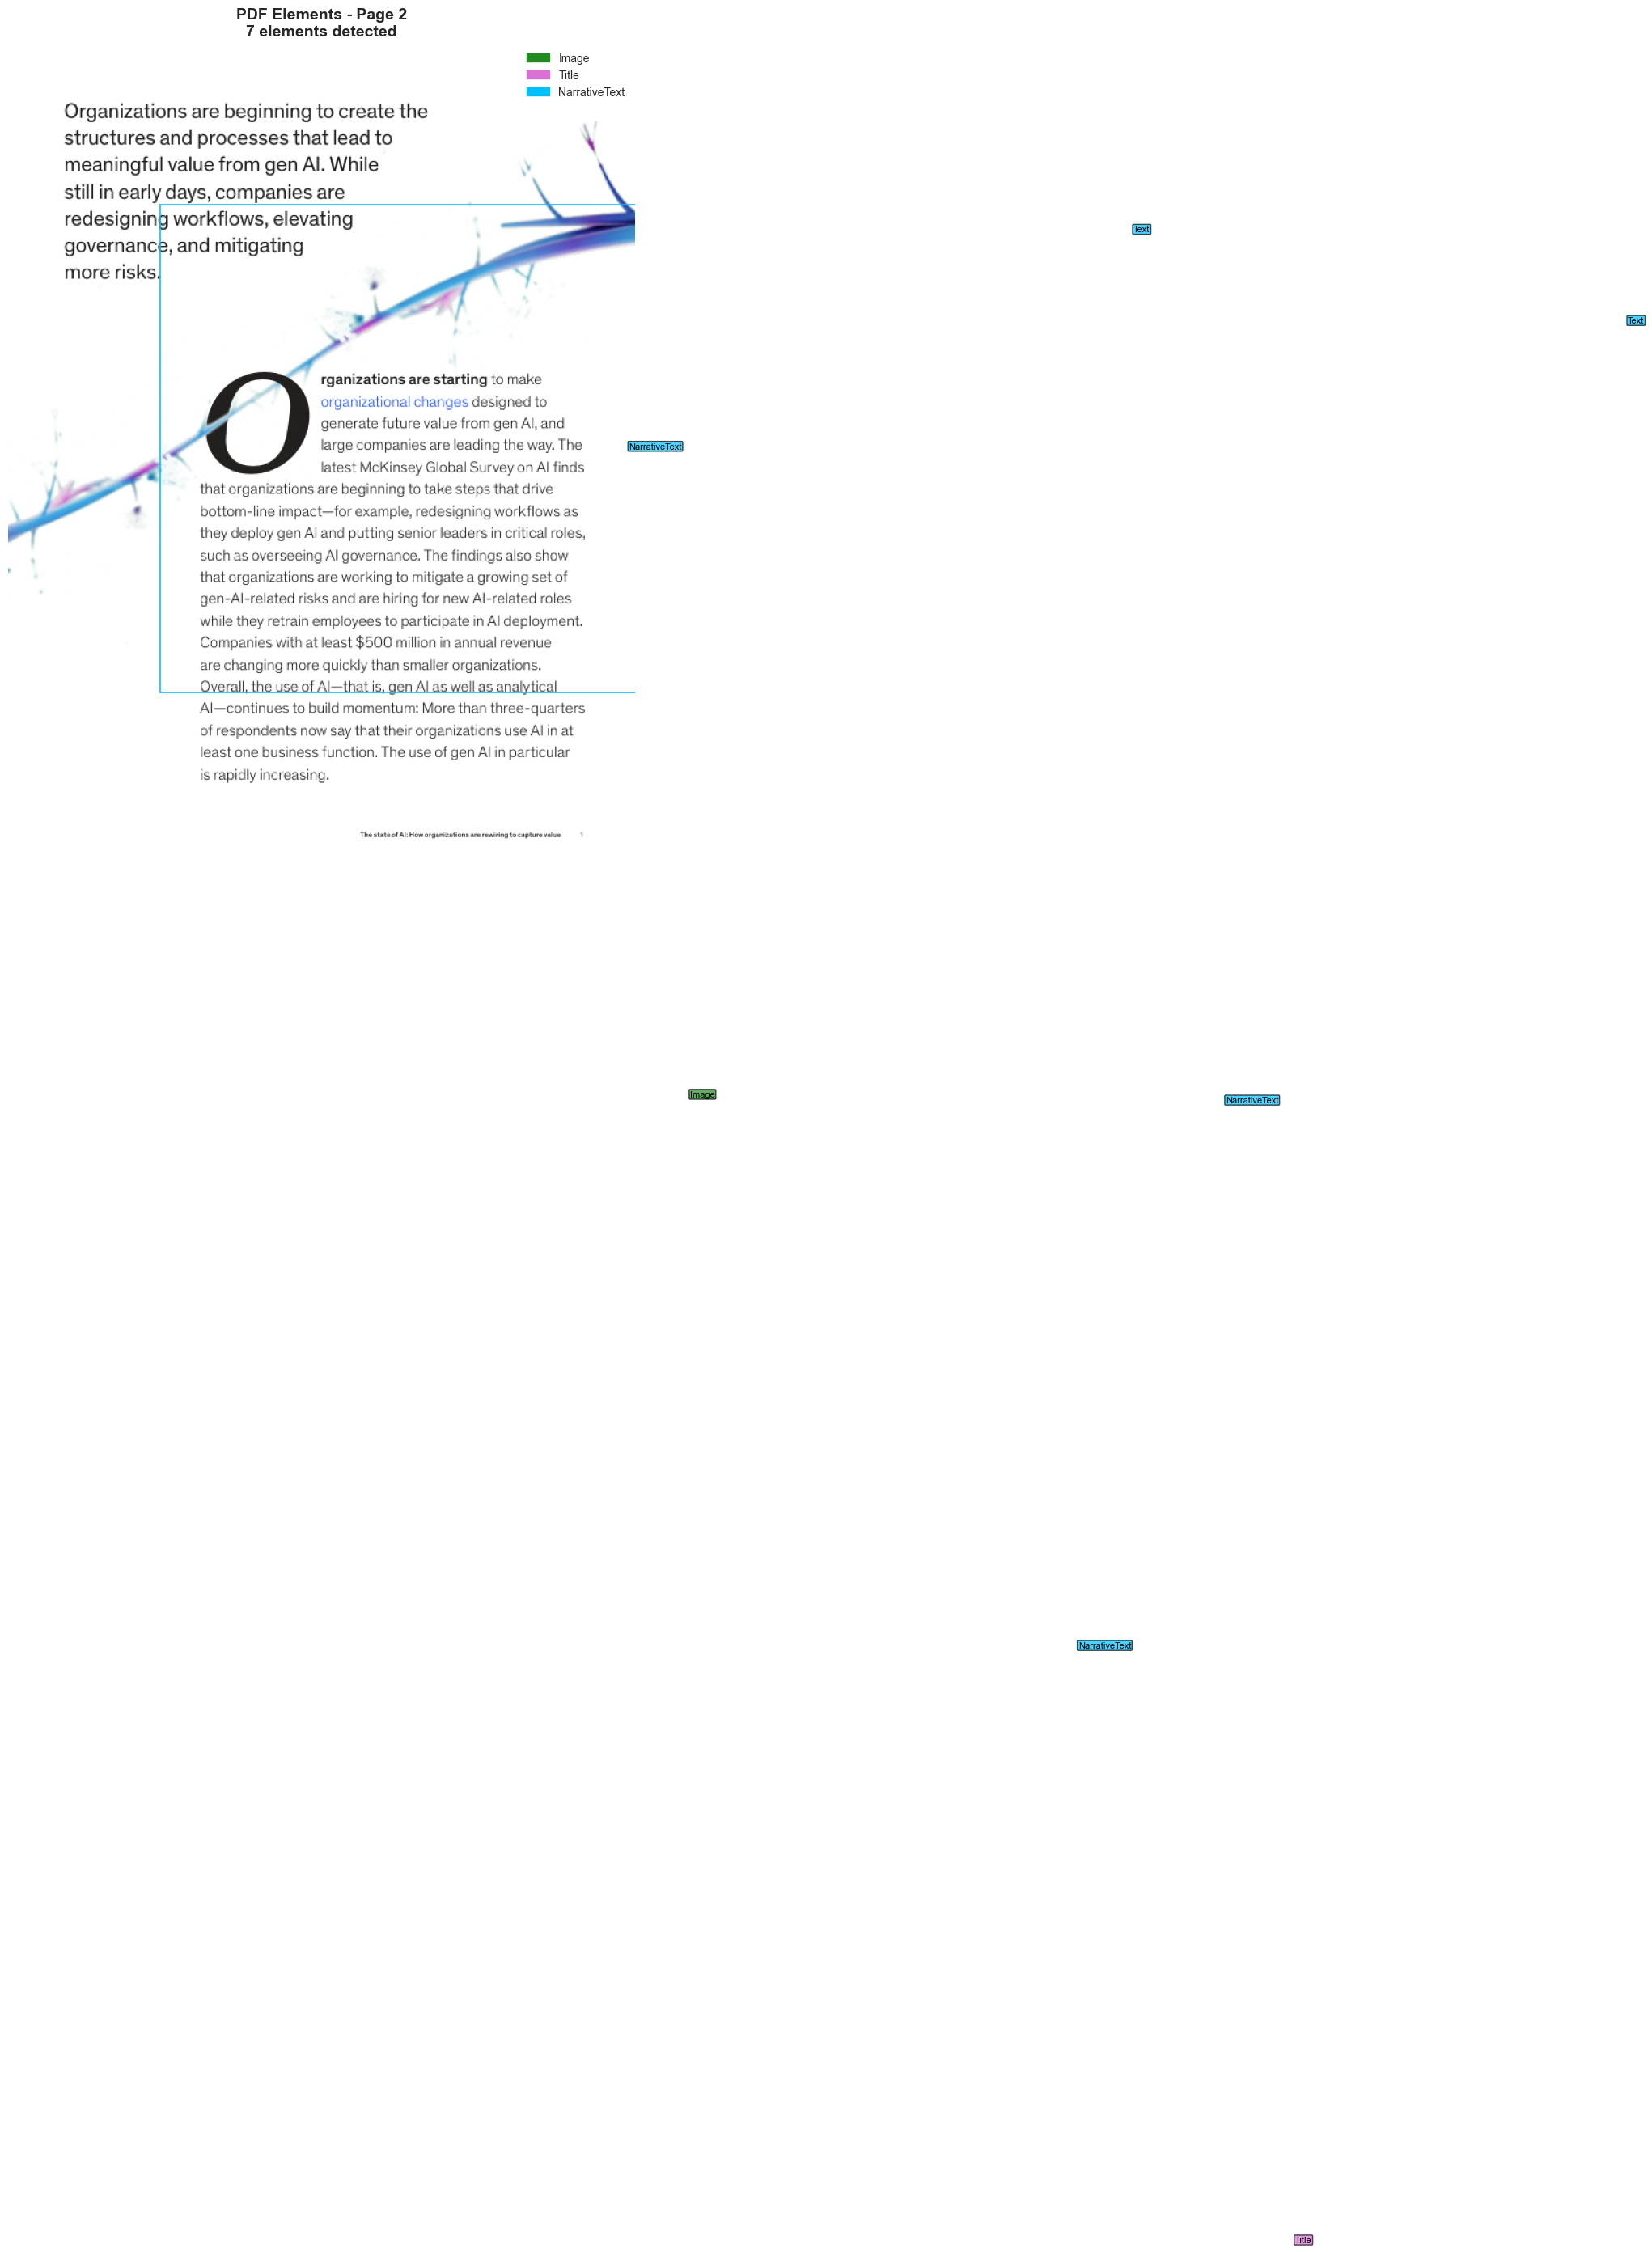

In [10]:
# Configuration: Which page to visualize
PAGE_NUM = 1  # Page number (0-based index)
DPI = 200  # Higher DPI for better quality

# Element colors by type
element_colors = {
    "Title": "#FF6B6B",
    "NarrativeText": "#4ECDC4", 
    "ListItem": "#FFD93D",
    "Table": "#95E1D3",
    "Image": "#F38181",
    "Header": "#AA96DA",
    "Footer": "#FCBAD3",
    "FigureCaption": "#F8B500",
    "PageNumber": "#C7CEEA"
}

print(f"Preparing visualization for Page {PAGE_NUM + 1}...")
print("=" * 60)

# Demonstrate render_page function (alternative visualization)
print("Alternative visualization using element coordinates:")
print("-" * 50)
print("Running render_page() for direct coordinate-based visualization")
render_page(elements, PDF_PATH, page_number=PAGE_NUM+1, print_text=False)

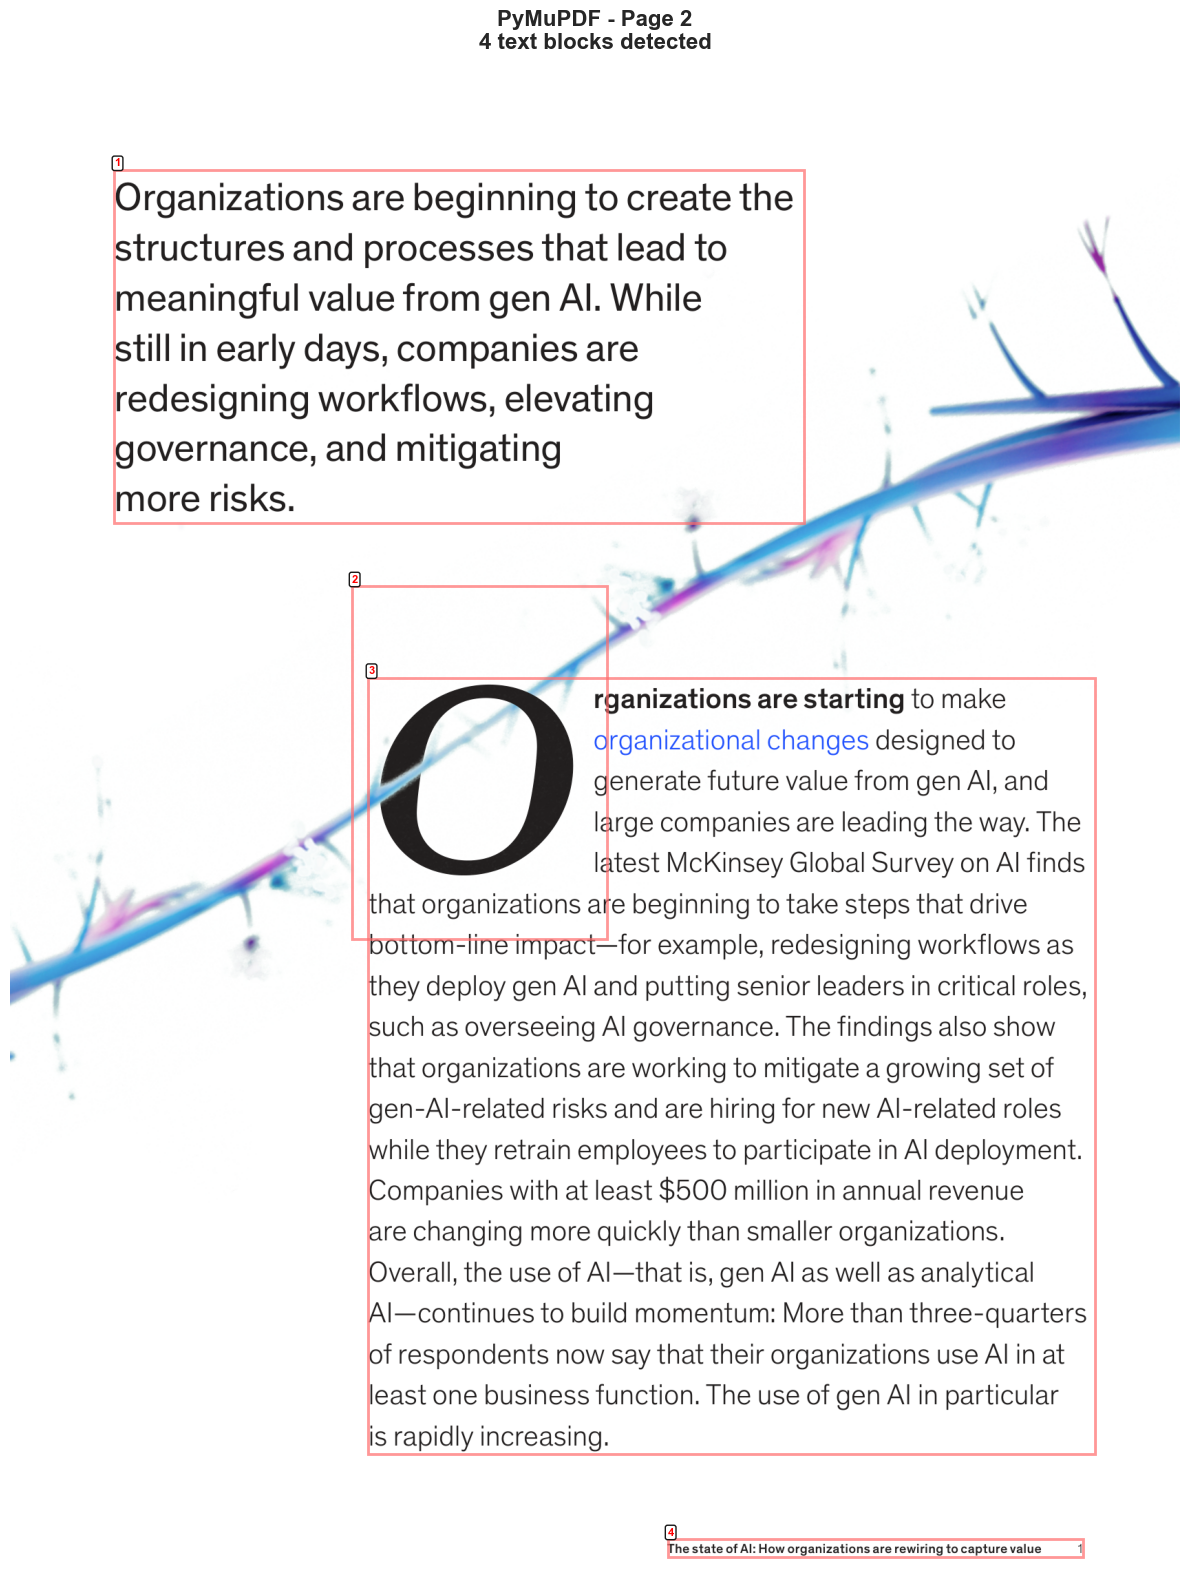

Visualizing page 2 using text search method...


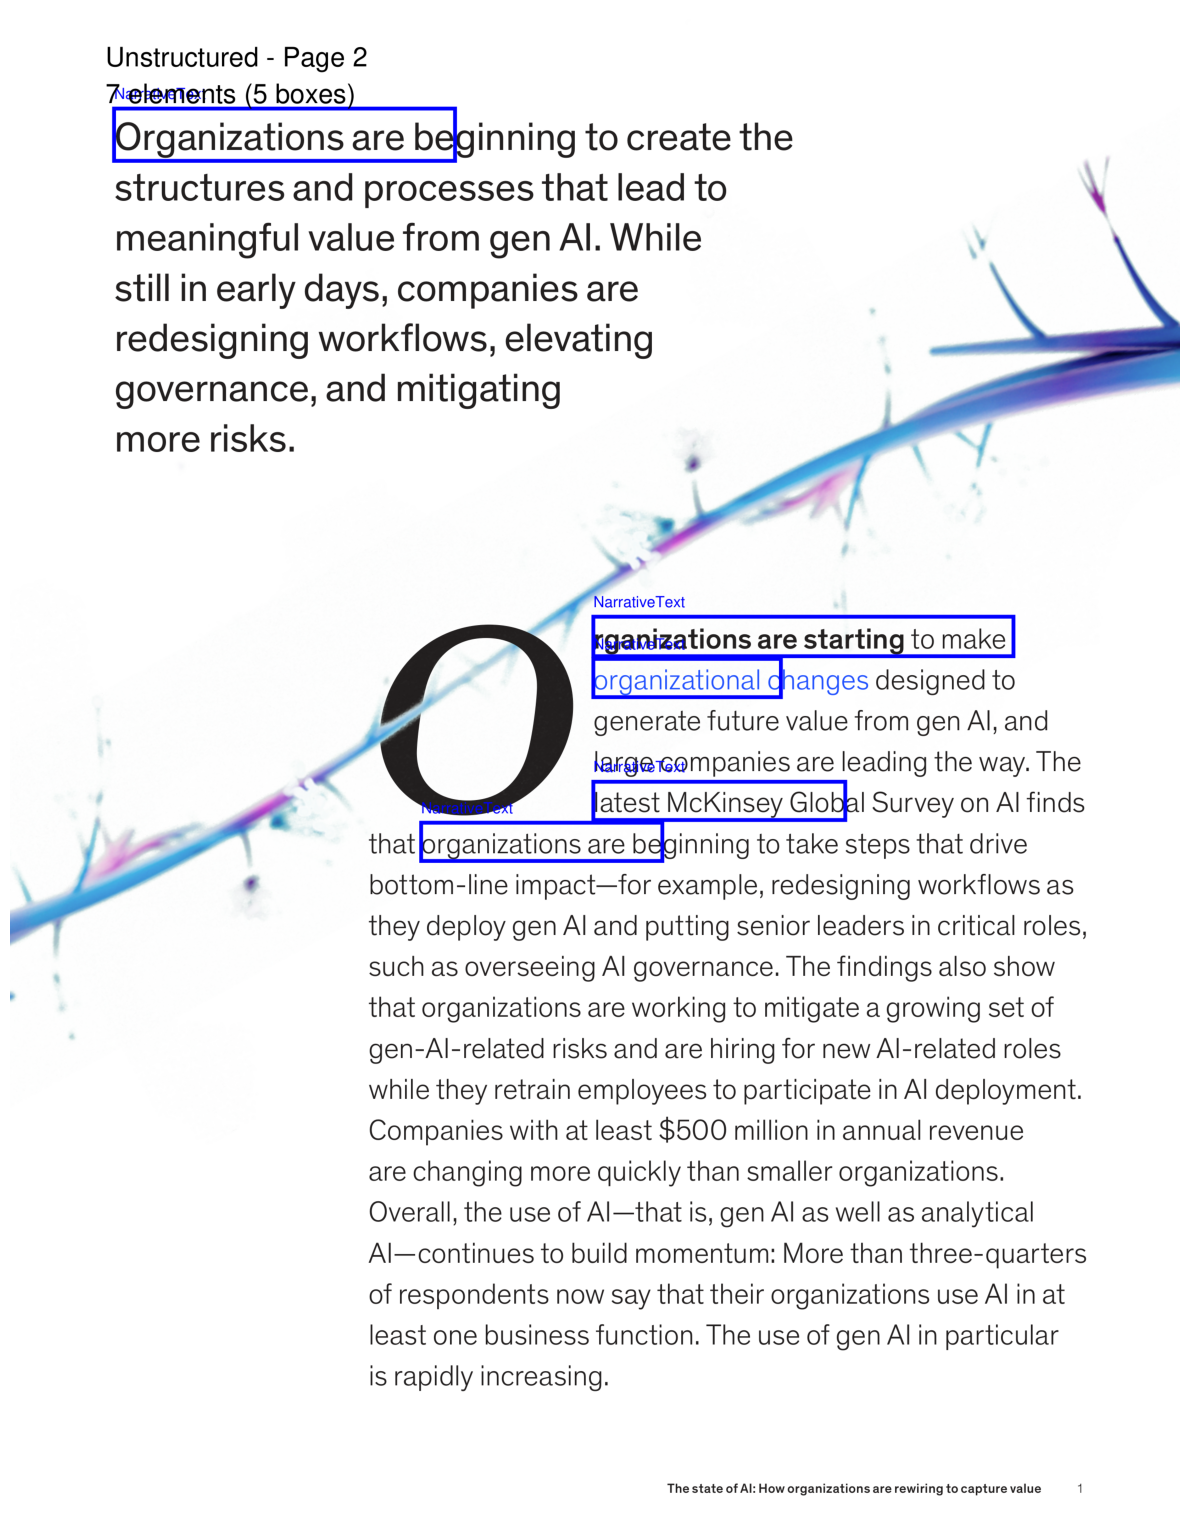

In [11]:
# Page-by-page comparison (separate visualizations)
# PyMuPDF and Unstructured plotted in separate figures

# Config
PAGE_NUM = PAGE_NUM if 'PAGE_NUM' in globals() else 7
DPI = DPI if 'DPI' in globals() else 200

# Figure 1: PyMuPDF blocks
fig1, ax1 = plt.subplots(1, 1, figsize=(12, 16))

doc = fitz.open(PDF_PATH)
if PAGE_NUM >= doc.page_count:
    print(f"Error: Page {PAGE_NUM} doesn't exist. PDF has {doc.page_count} pages.")
    doc.close()
else:
    page = doc[PAGE_NUM]
    pix = page.get_pixmap(dpi=DPI)
    img = Image.frombytes('RGB', [pix.width, pix.height], pix.samples)
    img_w, img_h = pix.width, pix.height

    ax1.imshow(img)
    blocks = page.get_text('dict')['blocks']
    pymupdf_block_count = 0
    for idx, block in enumerate(blocks):
        if 'lines' in block:
            x0, y0, x1, y1 = block['bbox']
            s = DPI / 72.0
            px0, py0 = x0 * s, y0 * s
            w, h = (x1 - x0) * s, (y1 - y0) * s
            ax1.add_patch(patches.Rectangle((px0, py0), w, h, linewidth=2, edgecolor='#FF6B6B', facecolor='none', alpha=0.7))
            ax1.text(px0, py0 - 5, str(idx + 1), fontsize=8, color='red', fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
            pymupdf_block_count += 1
    ax1.set_title(f"PyMuPDF - Page {PAGE_NUM + 1}\n{pymupdf_block_count} text blocks detected", fontsize=16, fontweight='bold', pad=15)
    ax1.axis('off')
    plt.tight_layout()
    plt.show()

    # Figure 2: Unstructured elements (using PyMuPDF's direct text search)
    print(f"Visualizing page {PAGE_NUM + 1} using text search method...")
    
    # Create custom colors for better visibility (RGB tuples)
    element_colors = {
        "Title": (1, 0, 0),         # Red
        "NarrativeText": (0, 0, 1),  # Blue
        "ListItem": (1, 0.65, 0),    # Orange
        "Table": (0, 0.8, 0),        # Green
        "Image": (1, 0, 1),          # Magenta
        "Header": (0.5, 0, 0.5),     # Purple
        "Footer": (0, 0.5, 0.5),     # Teal
        "FigureCaption": (1, 0.84, 0), # Gold
        "PageNumber": (0.5, 0.5, 0.5), # Gray
        "Text": (0.5, 0.25, 0),      # Brown
    }
    
    # Use higher DPI for better quality
    DPI_HIGH = 300
    
    _ = highlight_unstructured_elements(
        PDF_PATH, 
        elements, 
        page_num=PAGE_NUM, 
        dpi=DPI_HIGH, 
        element_colors=element_colors
    )
    plt.tight_layout()
    plt.show()

doc.close()


In [12]:
## PDF to Markdown Export Function

def save_pdf_to_markdown(pdf_path, output_file="output.md", output_dir="pdf_images", use_paddleocr=True):
    """
    Complete function to convert PDF to Markdown and save both the Markdown file
    and extracted images to disk.
    
    Args:
        pdf_path: Path to the PDF file
        output_file: Markdown output filename
        output_dir: Directory for extracted images
        use_paddleocr: Whether to use PaddleOCR for text recognition
    
    Returns:
        Tuple of (output_file_path, number of elements, number of images extracted)
    """
    from unstructured.partition.pdf import partition_pdf
    import os
    import time
    
    print(f"Converting {pdf_path} to Markdown...")
    start_time = time.time()
    
    # Prepare OCR parameters
    ocr_params = {
        "strategy": "hi_res",
        "infer_table_structure": True,
    }
    
    # Add PaddleOCR configuration if available and requested
    try:
        import importlib.util
        paddle_spec = importlib.util.find_spec("paddleocr")
        paddle_installed = paddle_spec is not None
        
        if paddle_installed and use_paddleocr:
            ocr_params.update({
                "languages": ["en", "zh"],
                "ocr_languages": "chi_sim+eng",
                "ocr_engine": "paddleocr"
            })
            print("Using PaddleOCR for text recognition")
        else:
            print("Using default OCR engine")
    except ImportError:
        print("PaddleOCR not available, using default OCR")
    
    # Step 1: Extract structured elements from PDF
    elements = partition_pdf(filename=pdf_path, **ocr_params)
    
    # Step 2: Convert to Markdown with image extraction
    try:
        # Check if html2text is available
        import importlib.util
        html2text_spec = importlib.util.find_spec("html2text")
        html2text_installed = html2text_spec is not None
        
        if html2text_installed:
            # Use enhanced conversion
            import html2text as html2text_converter
            md_content, img_count = pdf_to_markdown_with_images(elements, pdf_path, output_dir)
        else:
            # Fallback to simple conversion
            print("Warning: html2text not installed. Tables might not format correctly.")
            md_content, img_count = pdf_to_markdown_with_images(elements, pdf_path, output_dir)
    except Exception as e:
        print(f"Error during Markdown conversion: {e}")
        # Simple fallback without image extraction
        md_content = "\n\n".join([f"# {type(e).__name__}: {str(e)}\n\n"] + 
                               [str(elem) for elem in elements])
        img_count = 0
    
    # Step 3: Save Markdown file
    with open(output_file, "w", encoding="utf-8") as f:
        f.write(md_content)
    
    elapsed_time = time.time() - start_time
    print(f"✅ Conversion completed in {elapsed_time:.2f}s")
    print(f"  - {len(elements)} elements processed")
    print(f"  - {img_count} images extracted to {output_dir}/")
    print(f"  - Markdown saved to {output_file}")
    
    return output_file, len(elements), img_count

# Example usage (commented out to avoid running automatically)
"""
save_pdf_to_markdown(
    pdf_path="the-state-of-ai-how-organizations-are-rewiring-to-capture-value_final.pdf",
    output_file="state_of_ai.md",
    output_dir="state_of_ai_images"
)
"""


'\nsave_pdf_to_markdown(\n    pdf_path="the-state-of-ai-how-organizations-are-rewiring-to-capture-value_final.pdf",\n    output_file="state_of_ai.md",\n    output_dir="state_of_ai_images"\n)\n'